In [1]:
import sys
import jax

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.linalg import sqrtm

from xp_gaussian import generate_data
sys.path.append("../")
from lib_jax.utils_plot import plot_trajectory

## Utils Plots

In [2]:
def plot_particles(particles_gd, n_epochs, particles_tgt=None, ax=None, n_plots=5, xmin=-1, xmax=1, ymin=-1, ymax=1):
    if ax is None:
        fig, ax = plt.subplots(1, n_plots, figsize=(n_plots*3, 3))
    
    epochs = np.linspace(0, n_epochs, n_plots, dtype=int)
    
    for i, e in enumerate(epochs):
        if particles_tgt is not None:
            ax[i].scatter(particles_tgt[:,0], particles_tgt[:,1])

        particles = particles_gd[e]
        ax[i].scatter(particles[:,0], particles[:,1])

        ax[i].set_title("Epoch "+str(e))
        ax[i].set_xlim(xmin, xmax)
        ax[i].set_ylim(ymin, ymax)

In [3]:
# ---- Target Gaussian density ----
def gaussian_density(x, mean, cov):
    d = mean.shape[0]
    cov_inv = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    
    diff = x - mean
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=-1)
    
    norm_const = 1.0 / np.sqrt((2 * np.pi)**d * det_cov)
    return norm_const * np.exp(exponent)


def subsample_particles(particles_gd, n_top_x=5, n_top_y=5, n_random=10):
    """
    particles_gd: array (T, N, 2)
    retourne les indices des particules sélectionnées
    """
    final_particles = particles_gd[-1]  # shape (N, 2)

    # ---- top x ----
    idx_top_x = np.argsort(final_particles[:, 0])[-n_top_x:]

    # ---- top y ----
    idx_top_y = np.argsort(final_particles[:, 1])[-n_top_y:]

    # ---- combine ----
    selected = set(idx_top_x.tolist() + idx_top_y.tolist())

    # ---- random parmi le reste ----
    remaining = list(set(range(final_particles.shape[0])) - selected)

    idx_random = np.random.choice(
        remaining,
        size=min(n_random, len(remaining)),
        replace=False
    )

    selected.update(idx_random.tolist())

    return np.array(sorted(selected))


def plot_gaussian_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """
    Draws an ellipse representing the covariance matrix.
    
    n_std: number of standard deviations (e.g. 2 ≈ 95% mass)
    """
    # Eigen decomposition
    vals, vecs = np.linalg.eigh(cov)

    # Sort eigenvalues (largest first)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    # Compute angle
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    # Width and height (scaled by n_std)
    width, height = 2 * n_std * np.sqrt(vals)

    from matplotlib.patches import Ellipse
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=theta,
        fill=False,
        **kwargs
    )

    ax.add_patch(ellipse)


# ---- Plot function with density background ----
def plot_particles_with_density(
    particles_gd,
    epoch,
    particles_tgt=None,
    n_plots=5,
    xmin=-3, xmax=8,
    ymin=-3, ymax=8,
    grid_size=200,
    ax=None,
    title=None,
    target="gaussian"
):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    # ---- Create grid for density ----
    x = np.linspace(xmin, xmax, grid_size)
    y = np.linspace(ymin, ymax, grid_size)
    X, Y = np.meshgrid(x, y)
    grid = np.stack([X.ravel(), Y.ravel()], axis=1)

    # ---- Target distribution params ----
    if target == "gaussian":
        mean = np.array([0.0, 0.0])
        cov = np.array([[1.0, 0.5], [0.5, 1.0]])
    
        Z = gaussian_density(grid, mean, cov)

        for ns in [0.1, 0.5, 1, 2, 3]:
            plot_gaussian_ellipse(ax, mean, cov, n_std=ns, alpha=0.3)
    elif target=="gaussian_mixture":
        weights = jnp.array([1/3,1/3,1/3])
        means = jnp.array([[0,0],[3,-1],[1,4]])
        covs = jnp.array([[[1,1/2],[1/2,2]], [[1,0],[0,1]], [[3,1/2],[1/2,1]]])

        Z = 0

        for (weight, mean, cov) in zip(weights, means, covs):
            for ns in [0.1, 0.5, 1, 2, 3]:
                plot_gaussian_ellipse(ax, mean, cov, n_std=ns, alpha=0.3)
            Z += weight * gaussian_density(grid, mean, cov)        

    Z = Z.reshape(X.shape)

    # ---- Plot density as background ----
    ax.contourf(X, Y, Z, levels=20, alpha=0.6, cmap="Blues")

    # Optional: contour
    # ax.contour(X, Y, Z, levels=10, linewidths=0.5)



    # ---- Plot target samples ----
    if particles_tgt is not None:
        ax.scatter(
            particles_tgt[:, 0],
            particles_tgt[:, 1],
            s=5,
            alpha=0.3,
            label="Target"
        )

    # ---- Plot particles ----
    particles = particles_gd[epoch]
    ax.scatter(
        particles[:, 0],
        particles[:, 1],
        s=10,
        color="red",
        label=r"$\nu$"
    )

    x0 = particles_gd[0]
    ax.scatter(
        x0[:, 0],
        x0[:, 1],
        s=10,
        color="blue",
        label=r"$\mu_0$"
    )

    # ax.set_title(f"Epoch {epoch}")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    for p in range(particles.shape[0]):
        traj = particles_gd[:epoch, p, :]
        ax.plot(traj[:, 0], traj[:, 1], color="black", alpha=0.1)

    if title is not None:
        ax.set_title(title, fontsize=15)

In [7]:
def plot_convergence(mean_loss, std_loss, label="", color="red", period_subsample=4, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    
    n_x = len(mean_loss)
    x_axis = np.arange(n_x)

    # Plotting
    ax.plot(x_axis[::period_subsample], mean_loss[::period_subsample], label=label, lw=2, color=color)
    ax.fill_between(
        x_axis[::period_subsample], 
        mean_loss[::period_subsample]-std_loss[::period_subsample],
        mean_loss[::period_subsample]+std_loss[::period_subsample],
        alpha=0.2, color=color
    )

    ax.set_yscale("log")

    # Force a major tick at every power of 10
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))

    # Force the "little ticks" (2 through 9) between powers of 10
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=15))

    # Remove scientific notation for minor ticks to keep it clean (labels only on major)
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    # ax.set_xscale("log")
    # X-axis minor ticks
    # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax.set_xticks([0, 20_000, 40_000, 60_000, 80_000, 100_000, 120_000, 140_000, 160_000, 180_000, 200_000])
    # ax.set_xticklabels(["0", r"$2.5 \cdot 10^4$", r"$5\cdot 10^4$", r"$7.5\cdot 10^4$", r"$10^5$", r"$1.25\cdot 10^5$", r"$1.5\cdot 10^5$",
    #                     r"$1.75\cdot 10^5$", r"$2\cdot 10^5$"])

    ax.set_xticklabels(["0", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$", r"$1$", r"$1.2$", r"$1.4$",
                        r"$1.6$", r"$1.8$", r"$2$"])
    
    # Style the ticks
    ax.tick_params(axis='y', which='major', labelsize=12, length=8, width=1.5)
    ax.tick_params(axis='y', which='minor', length=4, width=1, color='gray')
    ax.tick_params(axis='x', which='major', labelsize=11, length=6)

    # Grid styling
    ax.grid(True, which="major", ls="-", alpha=0.5, lw=1)
    ax.grid(True, which="minor", ls=":", alpha=0.3)

    ax.set_ylabel(r"$\mathrm{MMD}^2(\mu_k, \nu)$", fontsize=15)
    ax.set_xlabel(r"Outer Iterations ($\times 10^5$), $K$=200K", fontsize=15)
    ax.legend(fontsize=15, frameon=True)

## Gaussian Target

In [5]:
bandwidth = 10.0 # 10.0

L_gd = np.loadtxt("./results/cv_mmd/convergence_gaussian_gd_h"+str(bandwidth)+".csv", delimiter=",")
L_cccp = np.loadtxt("./results/cv_mmd/convergence_gaussian_cccp_h"+str(bandwidth)+".csv", delimiter=",")
L_cccp_luu = np.loadtxt("./results/cv_mmd/convergence_gaussian_cccp_luu_h"+str(bandwidth)+".csv", delimiter=",")
L_cccp_signed = np.loadtxt("./results/cv_mmd/convergence_gaussian_cccp_jordan_decomposition_h"+str(bandwidth)+".csv", delimiter=",")

L_fb = np.loadtxt("./results/cv_mmd/convergence_gaussian_fb_h"+str(bandwidth)+".csv", delimiter=",")
L_fb_luu = np.loadtxt("./results/cv_mmd/convergence_gaussian_fb_luu_h"+str(bandwidth)+".csv", delimiter=",")
L_fb_signed = np.loadtxt("./results/cv_mmd/convergence_gaussian_fb_jordan_decomposition_h"+str(bandwidth)+".csv", delimiter=",")


particles_gd = np.load("./results/cv_mmd/particles_gaussian_gd_h"+str(bandwidth)+".npy")
particles_cccp = np.load("./results/cv_mmd/particles_gaussian_cccp_h"+str(bandwidth)+".npy")
particles_cccp_luu = np.load("./results/cv_mmd/particles_gaussian_cccp_luu_h"+str(bandwidth)+".npy")
particles_cccp_signed = np.load("./results/cv_mmd/particles_gaussian_cccp_jordan_decomposition_h"+str(bandwidth)+".npy")

particles_fb = np.load("./results/cv_mmd/particles_gaussian_fb_h"+str(bandwidth)+".npy")
particles_fb_luu = np.load("./results/cv_mmd/particles_gaussian_fb_luu_h"+str(bandwidth)+".npy")
particles_fb_signed = np.load("./results/cv_mmd/particles_gaussian_fb_jordan_decomposition_h"+str(bandwidth)+".npy")


mean_gd = np.mean(L_gd, axis=0)
std_gd = np.std(L_gd, axis=0)

mean_cccp = np.mean(L_cccp, axis=0)
std_cccp = np.std(L_cccp, axis=0)

mean_cccp_luu = np.mean(L_cccp_luu, axis=0)
std_cccp_luu = np.std(L_cccp_luu, axis=0)

mean_cccp_signed = np.mean(L_cccp_signed, axis=0)
std_cccp_signed = np.mean(L_cccp_signed, axis=0)


mean_fb = np.mean(L_fb, axis=0)
std_fb = np.std(L_fb, axis=0)

mean_fb_luu = np.mean(L_fb_luu, axis=0)
std_fb_luu = np.std(L_fb_luu, axis=0)

mean_fb_signed = np.mean(L_fb_signed, axis=0)
std_fb_signed = np.std(L_fb_signed, axis=0)

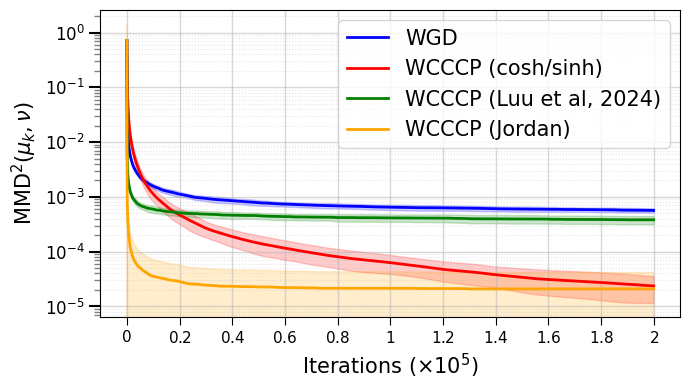

In [6]:
plt.figure(figsize=(7, 4))
ax = plt.gca()

plot_convergence(mean_gd, std_gd, label="WGD", color="blue", ax=ax, period_subsample=100)
plot_convergence(mean_cccp, std_cccp, label="WCCCP (cosh/sinh)", color="red", ax=ax, period_subsample=100)
plot_convergence(mean_cccp_luu, std_cccp_luu, label="WCCCP (Luu et al, 2024)", color="green", ax=ax, period_subsample=100)
plot_convergence(mean_cccp_signed, std_cccp_signed, label="WCCCP (Jordan)", color="orange", ax=ax, period_subsample=100)

plt.tight_layout()
# plt.savefig("./Figures/Convergence_MMD_Gaussian.pdf", format="pdf", bbox_inches="tight")
plt.show()

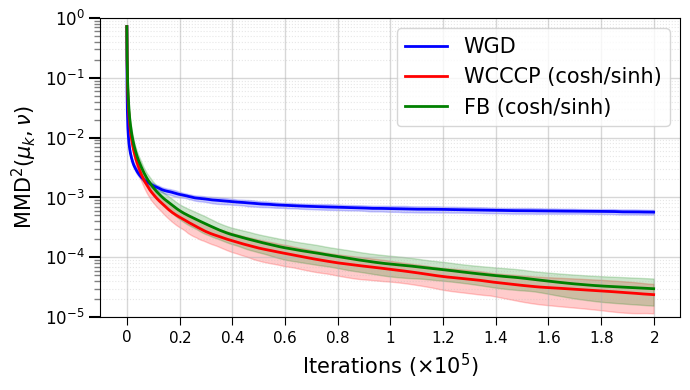

In [14]:
plt.figure(figsize=(7, 4))
ax = plt.gca()

plot_convergence(mean_gd, std_gd, label="WGD", color="blue", ax=ax, period_subsample=100)
plot_convergence(mean_cccp, std_cccp, label="WCCCP (cosh/sinh)", color="red", ax=ax, period_subsample=100)
plot_convergence(mean_fb, std_fb, label="FB (cosh/sinh)", color="green", ax=ax, period_subsample=100)

ax.set_ylim(1e-5, 1)
plt.tight_layout()
# plt.savefig("./Figures/Convergence_MMD_Gaussian_cosh_sinh.pdf", format="pdf", bbox_inches="tight")
plt.show()

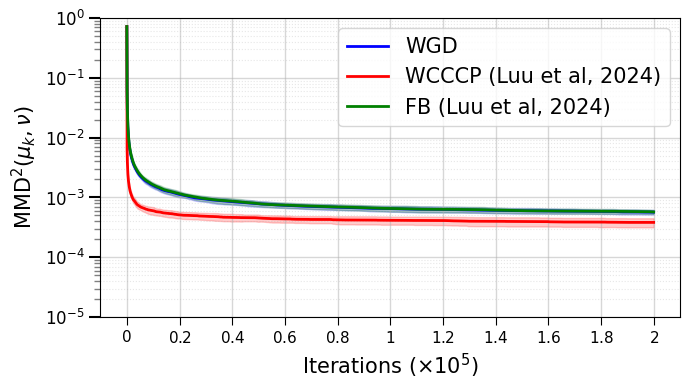

In [15]:
plt.figure(figsize=(7, 4))
ax = plt.gca()

plot_convergence(mean_gd, std_gd, label="WGD", color="blue", ax=ax, period_subsample=100)
plot_convergence(mean_cccp_luu, std_cccp_luu, label="WCCCP (Luu et al, 2024)", color="red", ax=ax, period_subsample=100)
plot_convergence(mean_fb_luu, std_fb_luu, label="FB (Luu et al, 2024)", color="green", ax=ax, period_subsample=100)

ax.set_ylim(1e-5, 1)
plt.tight_layout()
# plt.savefig("./Figures/Convergence_MMD_Gaussian_Luu.pdf", format="pdf", bbox_inches="tight")
plt.show()

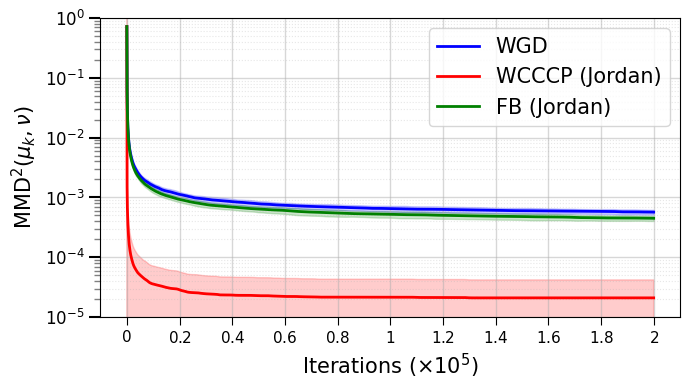

In [13]:
plt.figure(figsize=(7, 4))
ax = plt.gca()

plot_convergence(mean_gd, std_gd, label="WGD", color="blue", ax=ax, period_subsample=100)
plot_convergence(mean_cccp_signed, std_cccp_signed, label="WCCCP (Jordan)", color="red", ax=ax, period_subsample=100)
plot_convergence(mean_fb_signed, std_fb_signed, label="FB (Jordan)", color="green", ax=ax, period_subsample=100)

ax.set_ylim(1e-5, 1)
plt.tight_layout()
# plt.savefig("./Figures/Convergence_MMD_Gaussian.pdf", format="pdf", bbox_inches="tight")
plt.show()

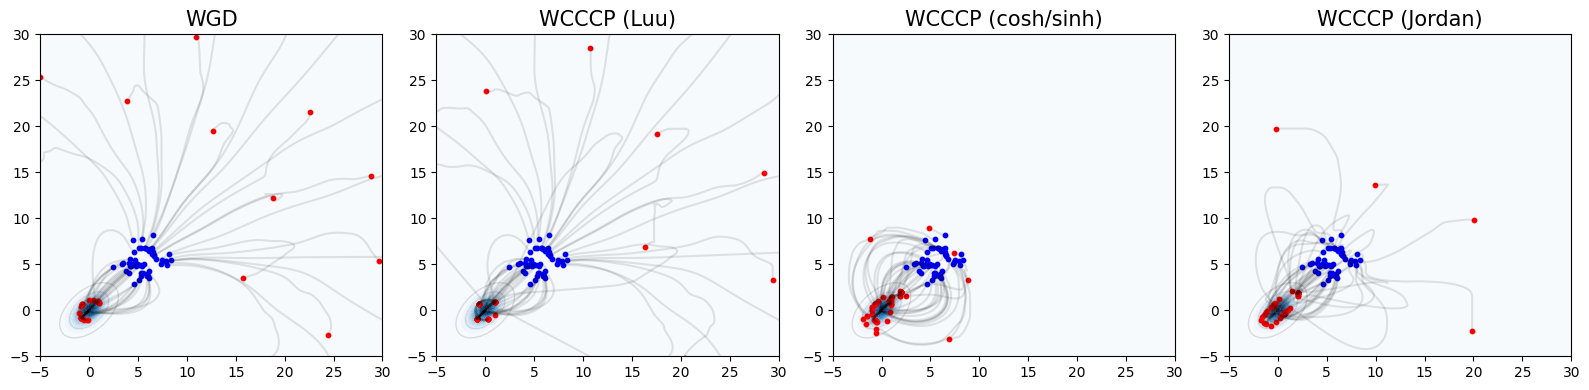

In [12]:
rng = jax.random.PRNGKey(42)

n_epochs, n_samples, d = particles_gd.shape
X_tgt, _ = generate_data(rng, n_samples=n_samples, d=d, target="gaussian")

sub_inds = subsample_particles(particles_gd, n_top_x=15, n_top_y=15, n_random=30)

fig, ax = plt.subplots(1, 4, figsize=(4*4, 4))
plot_particles_with_density(particles_gd[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[0], title="WGD")
plot_particles_with_density(particles_cccp_luu[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[1], title="WCCCP (Luu)")
plot_particles_with_density(particles_cccp[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[2], title="WCCCP (cosh/sinh)")
plot_particles_with_density(particles_cccp_signed[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[3], title="WCCCP (Jordan)")

plt.tight_layout()
# plt.savefig("./Figures/Particles_MMD_Gaussian.pdf", format="pdf", bbox_inches="tight")
plt.show()

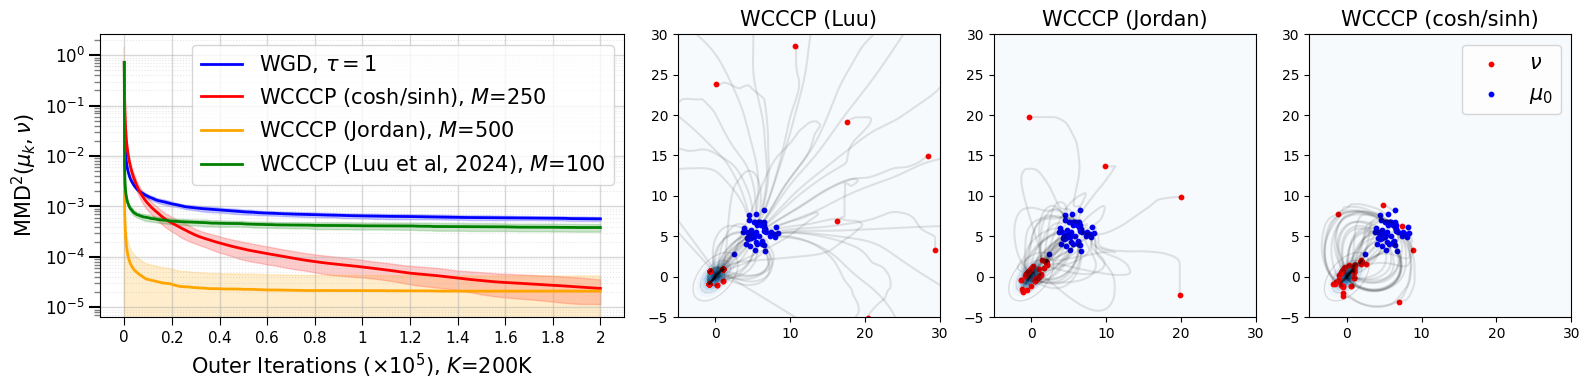

In [13]:
fig, ax = plt.subplots(
    1, 4,
    figsize=(16, 4),
    gridspec_kw={"width_ratios": [2, 1, 1, 1]}  # first plot 2 times wider
)

plot_convergence(mean_gd, std_gd, label=r"WGD, $\tau=1$", color="blue", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp, std_cccp, label=r"WCCCP (cosh/sinh), $M$=250", color="red", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp_signed, std_cccp_signed, label=r"WCCCP (Jordan), $M$=500", color="orange", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp_luu, std_cccp_luu, label=r"WCCCP (Luu et al, 2024), $M$=100", color="green", ax=ax[0], period_subsample=100)

rng = jax.random.PRNGKey(42)
n_epochs, n_samples, d = particles_gd.shape
X_tgt, _ = generate_data(rng, n_samples=n_samples, d=d, target="gaussian")
sub_inds = subsample_particles(particles_gd, n_top_x=15, n_top_y=15, n_random=30)

# plot_particles_with_density(particles_gd[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[1], title="WGD")
plot_particles_with_density(particles_cccp_luu[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[1], title="WCCCP (Luu)")
plot_particles_with_density(particles_cccp_signed[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[2], title="WCCCP (Jordan)")
plot_particles_with_density(particles_cccp[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[3], title="WCCCP (cosh/sinh)")

ax[3].legend(fontsize=15)

plt.tight_layout()
plt.savefig("./Figures/Fig_MMD_Gaussian_wcccp.pdf", format="pdf", bbox_inches="tight")

plt.show()

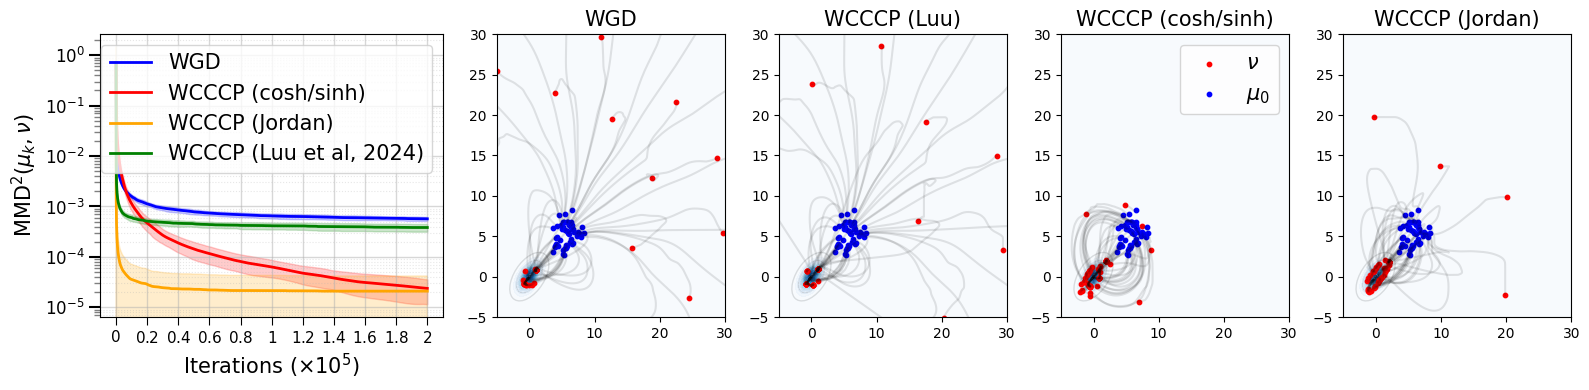

In [9]:
fig, ax = plt.subplots(
    1, 5,
    figsize=(16, 4),
    gridspec_kw={"width_ratios": [1.5, 1, 1, 1, 1]}  # first plot 2 times wider
)

plot_convergence(mean_gd, std_gd, label=r"WGD, $\tau=1$", color="blue", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp, std_cccp, label="WCCCP (cosh/sinh)", color="red", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp_signed, std_cccp_signed, label="WCCCP (Jordan)", color="orange", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp_luu, std_cccp_luu, label="WCCCP (Luu et al, 2024)", color="green", ax=ax[0], period_subsample=100)

rng = jax.random.PRNGKey(42)
n_epochs, n_samples, d = particles_gd.shape
X_tgt, _ = generate_data(rng, n_samples=n_samples, d=d, target="gaussian")
sub_inds = subsample_particles(particles_gd, n_top_x=15, n_top_y=15, n_random=30)

plot_particles_with_density(particles_gd[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[1], title="WGD")
plot_particles_with_density(particles_cccp_luu[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[2], title="WCCCP (Luu)")
plot_particles_with_density(particles_cccp[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[3], title="WCCCP (cosh/sinh)")
plot_particles_with_density(particles_cccp_signed[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[4], title="WCCCP (Jordan)")

ax[3].legend(fontsize=15)

plt.tight_layout()
# plt.savefig("./Figures/Fig_MMD_Gaussian.pdf", format="pdf", bbox_inches="tight")

plt.show()

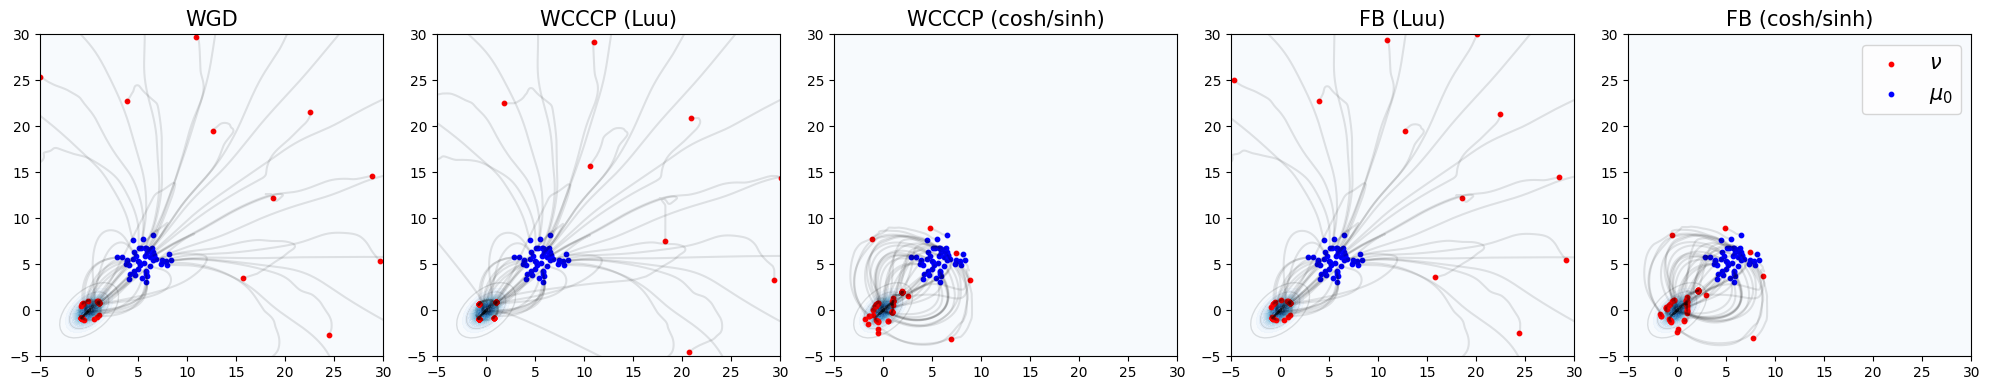

In [18]:
rng = jax.random.PRNGKey(42)

n_epochs, n_samples, d = particles_gd.shape
X_tgt, _ = generate_data(rng, n_samples=n_samples, d=d, target="gaussian")

sub_inds = subsample_particles(particles_gd, n_top_x=15, n_top_y=15, n_random=30)

fig, ax = plt.subplots(1, 5, figsize=(5*4, 4))
plot_particles_with_density(particles_gd[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[0], title="WGD")
plot_particles_with_density(particles_cccp_luu[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[1], title="WCCCP (Luu)")
plot_particles_with_density(particles_cccp[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[2], title="WCCCP (cosh/sinh)")
plot_particles_with_density(particles_fb_luu[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[3], title="FB (Luu)")
plot_particles_with_density(particles_fb[:, sub_inds, :], n_epochs-1, xmin=-5, xmax=30, ymin=-5, ymax=30, ax=ax[4], title="FB (cosh/sinh)")

ax[4].legend(fontsize=15)

plt.tight_layout()
# plt.savefig("./Figures/Particles_MMD_Gaussian_full.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Mixture of Gaussian Target

In [11]:
bandwidth = 10

L_gd = np.loadtxt("./results/cv_mmd/convergence_gaussian_mixture_gd_h"+str(bandwidth)+".csv", delimiter=",")
# L_cccp_implicit = np.loadtxt("./results/cv_mmd/convergence_gaussian_mixture_implicit_cccp.csv", delimiter=",")
L_cccp = np.loadtxt("./results/cv_mmd/convergence_gaussian_mixture_cccp_h"+str(bandwidth)+".csv", delimiter=",")
L_cccp_luu = np.loadtxt("./results/cv_mmd/convergence_gaussian_mixture_cccp_luu_h"+str(bandwidth)+".csv", delimiter=",")
L_fb = np.loadtxt("./results/cv_mmd/convergence_gaussian_mixture_fb.csv", delimiter=",")
L_fb_luu = np.loadtxt("./results/cv_mmd/convergence_gaussian_mixture_fb_luu.csv", delimiter=",")
L_cccp_signed = np.loadtxt("./results/cv_mmd/convergence_gaussian_mixture_cccp_jordan_decomposition_h"+str(bandwidth)+".csv", delimiter=",")

particles_gd = np.load("./results/cv_mmd/particles_gaussian_mixture_gd_h"+str(bandwidth)+".npy")
particles_cccp = np.load("./results/cv_mmd/particles_gaussian_mixture_cccp_h"+str(bandwidth)+".npy")
particles_cccp_luu = np.load("./results/cv_mmd/particles_gaussian_mixture_cccp_luu_h"+str(bandwidth)+".npy")
particles_fb = np.load("./results/cv_mmd/particles_gaussian_mixture_fb.npy")
particles_fb_luu = np.load("./results/cv_mmd/particles_gaussian_mixture_fb_luu.npy")
particles_cccp_signed = np.load("./results/cv_mmd/particles_gaussian_mixture_cccp_jordan_decomposition_h"+str(bandwidth)+".npy")

mean_gd = np.mean(L_gd, axis=0)
std_gd = np.std(L_gd, axis=0)

mean_cccp = np.mean(L_cccp, axis=0)
std_cccp = np.std(L_cccp, axis=0)

mean_cccp_luu = np.mean(L_cccp_luu, axis=0)
std_cccp_luu = np.std(L_cccp_luu, axis=0)

mean_fb = np.mean(L_fb, axis=0)
std_fb = np.std(L_fb, axis=0)

mean_fb_luu = np.mean(L_fb_luu, axis=0)
std_fb_luu = np.std(L_fb_luu, axis=0)

mean_cccp_signed = np.mean(L_cccp_signed, axis=0)
std_cccp_signed = np.mean(L_cccp_signed, axis=0)

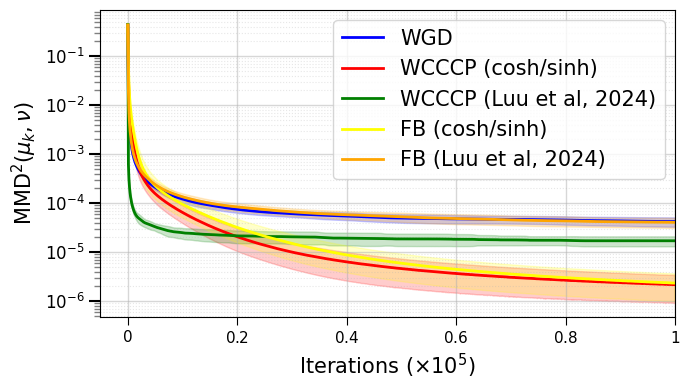

In [12]:
plt.figure(figsize=(7, 4))
ax = plt.gca()

plot_convergence(mean_gd, std_gd, label="WGD", color="blue", ax=ax, period_subsample=100)
plot_convergence(mean_cccp, std_cccp, label="WCCCP (cosh/sinh)", color="red", ax=ax, period_subsample=100)
plot_convergence(mean_cccp_luu, std_cccp_luu, label="WCCCP (Luu et al, 2024)", color="green", ax=ax, period_subsample=100)
plot_convergence(mean_fb, std_fb, label="FB (cosh/sinh)", color="yellow", ax=ax, period_subsample=100)
plot_convergence(mean_fb_luu, std_fb_luu, label="FB (Luu et al, 2024)", color="orange", ax=ax, period_subsample=100)
# plot_convergence(mean_cccp_signed, std_cccp_signed, label="WCCCP (Jordan)", color="orange", ax=ax, period_subsample=100)
plt.tight_layout()

plt.xlim(-5_000, 100_000)
# plt.savefig("./Figures/Convergence_MMD_Mixture.pdf", format="pdf", bbox_inches="tight")
plt.show()

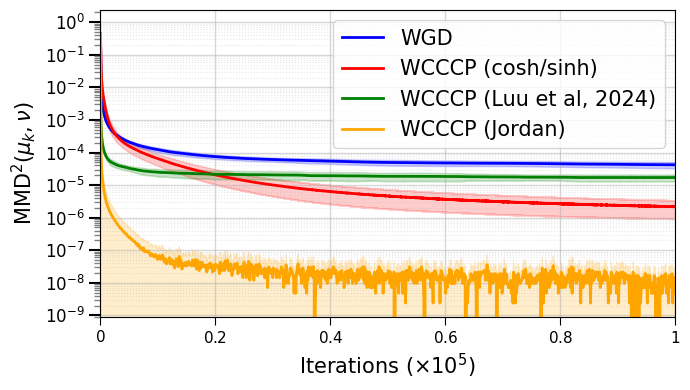

In [7]:
plt.figure(figsize=(7, 4))
ax = plt.gca()

plot_convergence(mean_gd, std_gd, label="WGD", color="blue", ax=ax)
plot_convergence(mean_cccp, std_cccp, label="WCCCP (cosh/sinh)", color="red", ax=ax)
plot_convergence(mean_cccp_luu, std_cccp_luu, label="WCCCP (Luu et al, 2024)", color="green", ax=ax)
plot_convergence(mean_cccp_signed, std_cccp_signed, label="WCCCP (Jordan)", color="orange", ax=ax, period_subsample=100)

plt.tight_layout()
# plt.savefig("./Figures/Convergence_MMD_Mixture.pdf", format="pdf", bbox_inches="tight")

plt.xlim(0, 100_000)
plt.show()

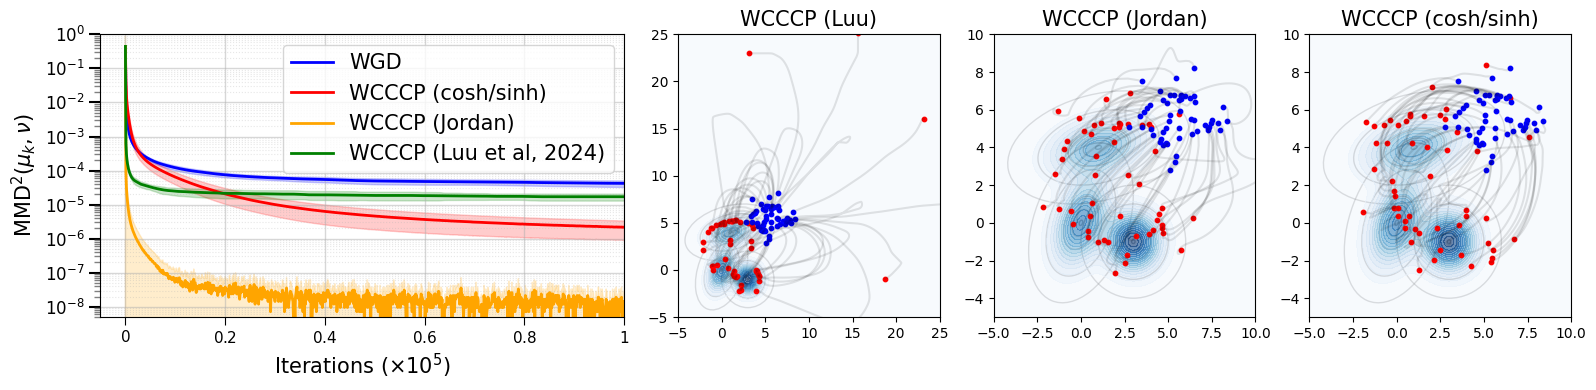

In [8]:
fig, ax = plt.subplots(
    1, 4,
    figsize=(16, 4),
    gridspec_kw={"width_ratios": [2, 1, 1, 1]}  # first plot 2 times wider
)

plot_convergence(mean_gd, std_gd, label="WGD", color="blue", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp, std_cccp, label="WCCCP (cosh/sinh)", color="red", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp_signed, std_cccp_signed, label="WCCCP (Jordan)", color="orange", ax=ax[0], period_subsample=100)
plot_convergence(mean_cccp_luu, std_cccp_luu, label="WCCCP (Luu et al, 2024)", color="green", ax=ax[0], period_subsample=100)

ax[0].set_xlim(-5_000, 100_000)
ax[0].set_ylim(5 * 10**(-9), 1)

rng = jax.random.PRNGKey(42)
n_epochs, n_samples, d = particles_gd.shape
X_tgt, _ = generate_data(rng, n_samples=n_samples, d=d, target="gaussian")
sub_inds = subsample_particles(particles_gd, n_top_x=15, n_top_y=15, n_random=30)

xmin, xmax = -5, 25
ymin, ymax = -5, 25

# plot_particles_with_density(particles_gd[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                            # ax=ax[1], title="WGD", target="gaussian_mixture")
plot_particles_with_density(particles_cccp_luu[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax, 
                            ax=ax[1], title="WCCCP (Luu)", target="gaussian_mixture")
plot_particles_with_density(particles_cccp_signed[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=10, ymin=ymin, ymax=10,
                            ax=ax[2], title="WCCCP (Jordan)", target="gaussian_mixture")
plot_particles_with_density(particles_cccp[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=10, ymin=ymin, ymax=10,
                            ax=ax[3], title="WCCCP (cosh/sinh)", target="gaussian_mixture")

plt.tight_layout()
# plt.savefig("./Figures/Fig_MMD_Mixture.pdf", format="pdf", bbox_inches="tight")

plt.show()

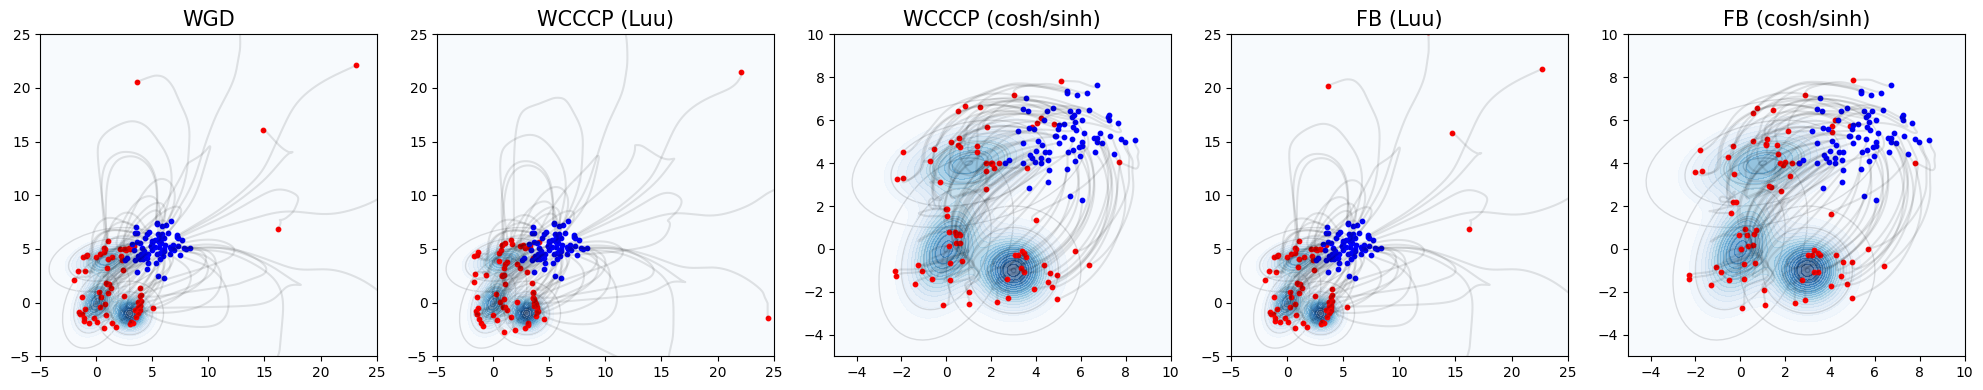

In [21]:
rng = jax.random.PRNGKey(42)

n_epochs, n_samples, d = particles_gd.shape
sub_inds = subsample_particles(particles_gd, n_top_x=15, n_top_y=15, n_random=50)

xmin, xmax = -5, 25
ymin, ymax = -5, 25

fig, ax = plt.subplots(1, 5, figsize=(5*4, 4))
plot_particles_with_density(particles_gd[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                            ax=ax[0], title="WGD", target="gaussian_mixture")
plot_particles_with_density(particles_cccp_luu[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                            ax=ax[1], title="WCCCP (Luu)", target="gaussian_mixture")
plot_particles_with_density(particles_cccp[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=10, ymin=ymin, ymax=10,
                            ax=ax[2], title="WCCCP (cosh/sinh)", target="gaussian_mixture")
plot_particles_with_density(particles_fb_luu[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                            ax=ax[3], title="FB (Luu)", target="gaussian_mixture")
plot_particles_with_density(particles_fb[:, sub_inds, :], n_epochs-1, xmin=xmin, xmax=10, ymin=ymin, ymax=10,
                            ax=ax[4], title="FB (cosh/sinh)", target="gaussian_mixture")

plt.tight_layout()
# plt.savefig("./Figures/Particles_MMD_mixture_full.pdf", format="pdf", bbox_inches="tight")
plt.show()